### Modelo CNN con Keras para reconocer dígitos del 0 al 9,
usando el dataset digitos_mnist_simple (imágenes de 8x8 píxeles en escala de grises)

1. Carga y preprocesamiento de los datos
2. Modelo base (CNN simple)
3. Evaluación del modelo base (accuracy, loss, matriz de confusión)
4. Optimización del modelo (hiperparámetros y regularización)
5. Comparación de resultados y comentarios


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Fijamos una semilla para que los resultados sean reproducibles
np.random.seed(42)
tf.random.set_seed(42)


1. Carga y preprocesamiento de los datos

- Hacer Reshape => pasar cada fila de a una  pseudo imagen de 8x8x1
- Hacer Normalización => dividir por 16 para que los valores queden entre 0 y 1.


In [2]:
df = pd.read_excel('digitos_mnist_simple.xlsx') # dataset
print("Filas y columnas:", df.shape)
df.head()

Filas y columnas: (1797, 65)


,0,1,2,3,4,5,6,7,8,9,...,55,56,57,58,59,60,61,62,63,label
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4


In [4]:
# separación de datos
X = df.drop(columns=['label']).values
y = df['label'].values

X = X.reshape(-1, 8, 8, 1).astype('float32') # Reshape
X = X / 16.0 # Normalización

print("Forma final de X:", X.shape)
print("Valor mínimo:", X.min(), "- Valor máximo:", X.max())


Forma final de X: (1797, 8, 8, 1)
Valor mínimo: 0.0 - Valor máximo: 1.0


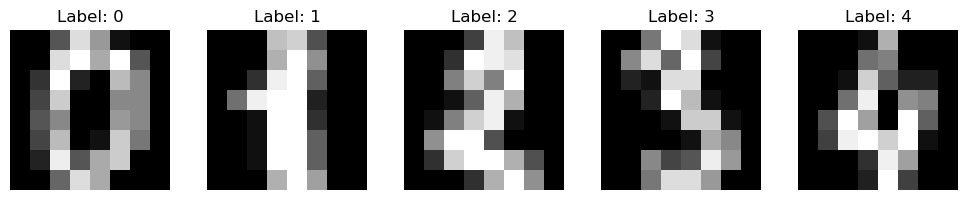

In [6]:
fig, axes = plt.subplots(1, 5, figsize=(10, 2)) # Revisar algunas imágenes y sus etiquetas
for i, ax in enumerate(axes):
    ax.imshow(X[i].reshape(8, 8), cmap='gray')
    ax.set_title(f"Label: {y[i]}")
    ax.axis('off')
plt.tight_layout()
plt.show()


In [7]:
# dividir en set de entrenamiento (80%) y de prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)


Entrenamiento: (1437, 8, 8, 1)
Prueba: (360, 8, 8, 1)


2. Modelo base (CNN simple)

CNN sencilla:
- Conv2D => detectar patrones locales en la imagen usando filtros.
- MaxPooling2D => reduce el tamaño de la imagen quedándose con los valores más importantes.
- Flatten => aplanar la imagen en un vector de una sola dimensión para poder pasarla a las capas densas.
- Dense => capas conectadas que hacen la clasificación final. Última capa con 10 neuronas (una por cada numero) con activación softmax, para probabilidad por clase.


In [9]:
tf.get_logger().setLevel('ERROR') # quitar warnings de TensorFlow

def crear_modelo_base():
    modelo = keras.Sequential([
        layers.Input(shape=(8, 8, 1)),                                  # imagen de entrada: 8x8 en escala de grises
        layers.Conv2D(16, (3, 3), activation='relu', padding='same'),   # 16 filtros que detectan patrones locales (bordes, trazos)
        layers.MaxPooling2D((2, 2)),                                    # reduce el mapa de características a la mitad, quedándose con lo más relevante
        layers.Flatten(),                                               # aplana el mapa 2D a un vector 1D para pasarlo a las capas densas
        layers.Dense(32, activation='relu'),                            # combina las características extraídas
        layers.Dense(10, activation='softmax')                          # salida: probabilidad para cada dígito (0-9)
    ])
    modelo.compile(optimizer='adam',
                    loss='sparse_categorical_crossentropy',
                    metrics=['accuracy'])
    return modelo

modelo_base = crear_modelo_base()
modelo_base.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 16)       │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 4, 4, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,714 (34.04 KB)

 Trainable params: 8,714 (34.04 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# entrenar el modelo base
historial_base = modelo_base.fit(
    X_train, y_train,
    epochs=20,
    batch_size=16,
    validation_split=0.2,
    verbose=2
)


Epoch 1/20
72/72 - 1s - 18ms/step - accuracy: 0.2950 - loss: 2.1201 - val_accuracy: 0.5382 - val_loss: 1.8491
Epoch 2/20
72/72 - 0s - 3ms/step - accuracy: 0.7755 - loss: 1.3250 - val_accuracy: 0.8368 - val_loss: 0.9560
Epoch 3/20
72/72 - 0s - 3ms/step - accuracy: 0.8851 - loss: 0.6297 - val_accuracy: 0.8785 - val_loss: 0.5597
Epoch 4/20
72/72 - 0s - 3ms/step - accuracy: 0.9147 - loss: 0.3918 - val_accuracy: 0.9028 - val_loss: 0.4127
Epoch 5/20
72/72 - 0s - 3ms/step - accuracy: 0.9295 - loss: 0.2952 - val_accuracy: 0.9097 - val_loss: 0.3313
Epoch 6/20
72/72 - 0s - 3ms/step - accuracy: 0.9391 - loss: 0.2384 - val_accuracy: 0.9236 - val_loss: 0.2783
Epoch 7/20
72/72 - 0s - 3ms/step - accuracy: 0.9495 - loss: 0.1992 - val_accuracy: 0.9271 - val_loss: 0.2428
Epoch 8/20
72/72 - 0s - 3ms/step - accuracy: 0.9626 - loss: 0.1699 - val_accuracy: 0.9375 - val_loss: 0.2182
Epoch 9/20
72/72 - 0s - 3ms/step - accuracy: 0.9634 - loss: 0.1478 - val_accuracy: 0.9410 - val_loss: 0.2004
Epoch 10/20
72/72 

3. Evaluación del modelo base

Revisar el accuracy y el loss en el set de prueba y los gráficos de la evolución del entrenamiento y la matriz de confusión.


In [17]:
# métricas en el set de prueba
loss_base, acc_base = modelo_base.evaluate(X_test, y_test, verbose=0)
print(f"Loss en test: {loss_base:.4f}")
print(f"Accuracy en test: {acc_base:.4f}")


Loss en test: 0.1296
Accuracy en test: 0.9583


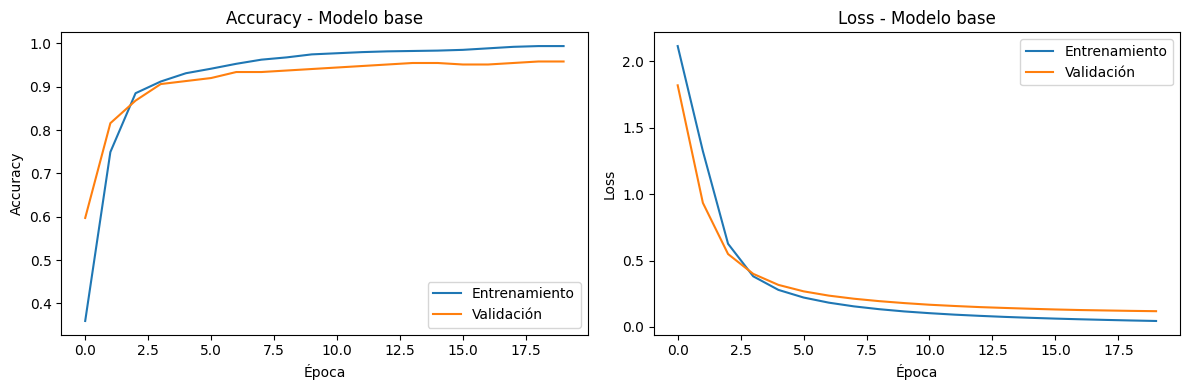

In [ ]:
# gráficos de accuracy y loss durante el entrenamiento
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(historial_base.history['accuracy'], label='Entrenamiento')
axes[0].plot(historial_base.history['val_accuracy'], label='Validación')
axes[0].set_title('Accuracy - Modelo base')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(historial_base.history['loss'], label='Entrenamiento')
axes[1].plot(historial_base.history['val_loss'], label='Validación')
axes[1].set_title('Loss - Modelo base')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()


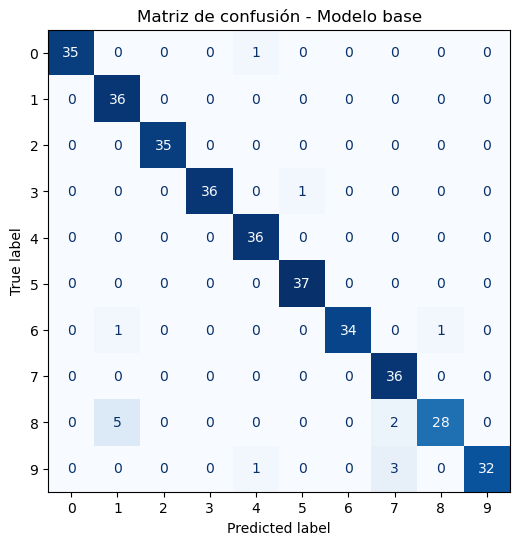

In [11]:
# matriz de confusión modelo base
y_pred_base = np.argmax(modelo_base.predict(X_test, verbose=0), axis=1)
cm_base = confusion_matrix(y_test, y_pred_base)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_base, display_labels=range(10))
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Matriz de confusión - Modelo base')
plt.show()


Con este modelo simple ya se obtiene un accuracy alto (sobre 95% => 345 / 360 = 0.958 ≈ 95.8%). 

La matriz de confusión muestra donde confunde más el modelo, lo ideal es que casi todos los
valores estén en la diagonal (predicción = valor real).


4. Optimización del modelo

Técnicas de mejora:

1. Ajuste de hiperparámetros => cambiar el batch_size (de 16 a 32) y usamos más epochs,
   dejando que EarlyStopping decida cuándo detener el entrenamiento.
2. Regularización => agregar capas Dropout, para apagar aleatoriamente un porcentaje de
   neuronas durante el entrenamiento para evitar que el modelo memorice los datos, y usar EarlyStopping para parar el entrenamiento cuando el modelo deja de mejorar
   en el set de validación.


In [12]:
def crear_modelo_optimizado():
    modelo = keras.Sequential([
        layers.Input(shape=(8, 8, 1)),                                  # imagen de entrada: 8x8 en escala de grises
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),   # más filtros (32) que el modelo base para captar más patrones
        layers.MaxPooling2D((2, 2)),                                    # reduce el mapa de características a la mitad
        layers.Dropout(0.3),                                            # apaga el 30% de las neuronas al azar para evitar que el modelo memorice datos
        layers.Flatten(),                                               # aplana el mapa 2D a un vector 1D
        layers.Dense(64, activation='relu'),                            # capa densa más grande (64) para combinar mejor las características
        layers.Dropout(0.3),                                            # segundo Dropout, mismo objetivo: regularizar
        layers.Dense(10, activation='softmax')                          # salida: probabilidad para cada dígito (0-9)
    ])
    modelo.compile(optimizer='adam',
                    loss='sparse_categorical_crossentropy',
                    metrics=['accuracy'])
    return modelo

modelo_opt = crear_modelo_optimizado()

# EarlyStopping => detiene el entrenamiento si el val_loss no mejora durante 5 épocas seguidas,
# y restaura los pesos de la mejor época (restore_best_weights=True)
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)

historial_opt = modelo_opt.fit(
    X_train, y_train,
    epochs=50,           # tope de épocas; en la práctica EarlyStopping corta antes
    batch_size=32,       # tamaño de lote más grande que el modelo base (16 -> 32)
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=2
)


Epoch 1/50
36/36 - 1s - 34ms/step - accuracy: 0.2889 - loss: 2.1452 - val_accuracy: 0.7604 - val_loss: 1.8942
Epoch 2/50
36/36 - 0s - 4ms/step - accuracy: 0.5909 - loss: 1.6263 - val_accuracy: 0.8299 - val_loss: 1.1985
Epoch 3/50
36/36 - 0s - 4ms/step - accuracy: 0.7433 - loss: 1.0516 - val_accuracy: 0.8819 - val_loss: 0.6979
Epoch 4/50
36/36 - 0s - 4ms/step - accuracy: 0.8233 - loss: 0.6820 - val_accuracy: 0.8958 - val_loss: 0.4717
Epoch 5/50
36/36 - 0s - 4ms/step - accuracy: 0.8607 - loss: 0.5204 - val_accuracy: 0.9028 - val_loss: 0.3761
Epoch 6/50
36/36 - 0s - 4ms/step - accuracy: 0.8764 - loss: 0.4366 - val_accuracy: 0.9062 - val_loss: 0.3253
Epoch 7/50
36/36 - 0s - 4ms/step - accuracy: 0.9077 - loss: 0.3574 - val_accuracy: 0.9028 - val_loss: 0.2907
Epoch 8/50
36/36 - 0s - 4ms/step - accuracy: 0.8973 - loss: 0.3230 - val_accuracy: 0.9236 - val_loss: 0.2449
Epoch 9/50
36/36 - 0s - 4ms/step - accuracy: 0.9130 - loss: 0.2912 - val_accuracy: 0.9340 - val_loss: 0.2095
Epoch 10/50
36/36 

#### Diagrama de la arquitectura (modelo optimizado)

Resumen visual de las capas del modelo optimizado, desde la imagen de entrada hasta la salida de 10 probabilidades:


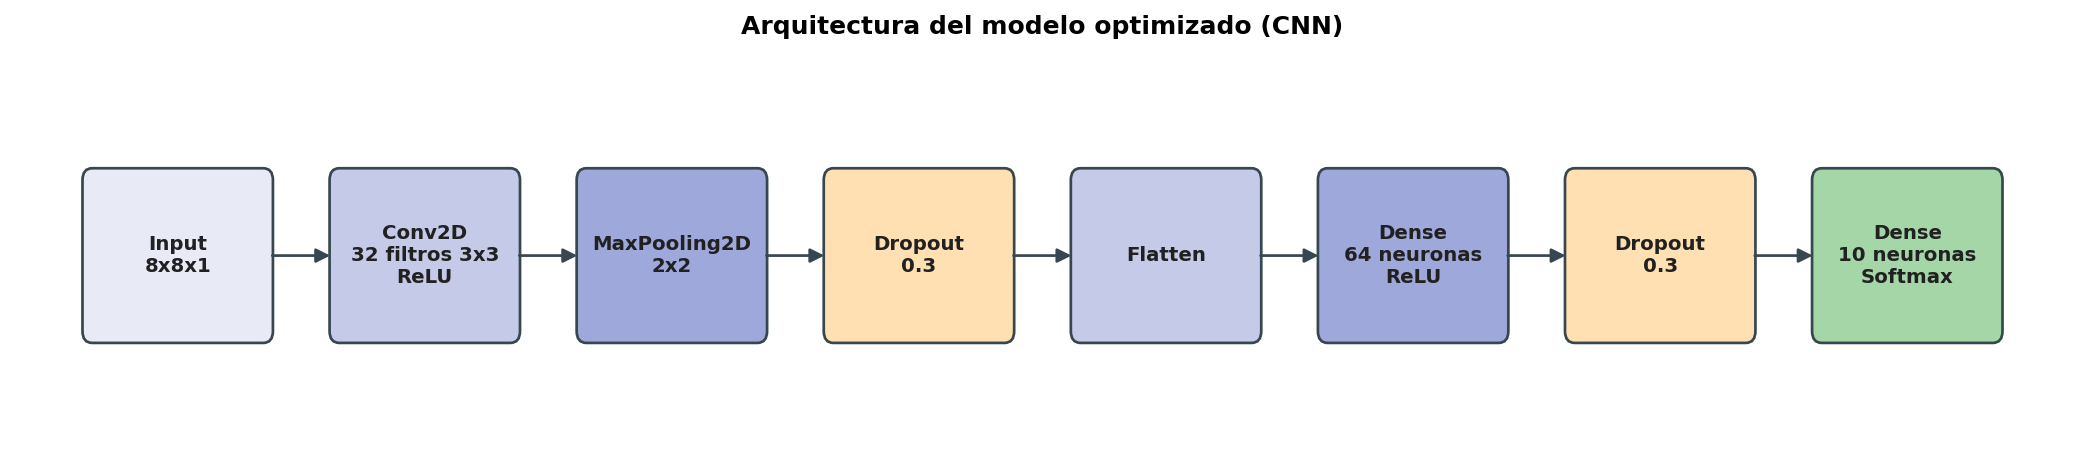

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

# Diagrama esquemático de la arquitectura (no requiere graphviz/pydot)
capas = [
    ("Input\n8x8x1", "#e8eaf6"),
    ("Conv2D\n32 filtros 3x3\nReLU", "#c5cae9"),
    ("MaxPooling2D\n2x2", "#9fa8da"),
    ("Dropout\n0.3", "#ffe0b2"),
    ("Flatten", "#c5cae9"),
    ("Dense\n64 neuronas\nReLU", "#9fa8da"),
    ("Dropout\n0.3", "#ffe0b2"),
    ("Dense\n10 neuronas\nSoftmax", "#a5d6a7"),
]

fig, ax = plt.subplots(figsize=(14, 3.2))
n = len(capas)
box_w, box_h, gap = 1.5, 1.1, 0.55
total_w = n * box_w + (n - 1) * gap
x = -total_w / 2
centers = []
for texto, color in capas:
    box = FancyBboxPatch((x, -box_h / 2), box_w, box_h,
                          boxstyle="round,pad=0.04,rounding_size=0.08",
                          linewidth=1.3, edgecolor="#37474f", facecolor=color)
    ax.add_patch(box)
    ax.text(x + box_w / 2, 0, texto, ha="center", va="center", fontsize=9.5, fontweight="bold")
    centers.append(x + box_w / 2)
    x += box_w + gap
for i in range(n - 1):
    arrow = FancyArrowPatch((centers[i] + box_w / 2, 0), (centers[i + 1] - box_w / 2, 0),
                             arrowstyle="-|>", mutation_scale=14, linewidth=1.3, color="#37474f")
    ax.add_patch(arrow)
ax.set_xlim(-total_w / 2 - 0.6, total_w / 2 + 0.6)
ax.set_ylim(-1.3, 1.3)
ax.axis("off")
ax.set_title("Arquitectura del modelo optimizado (CNN)", fontsize=12, fontweight="bold", pad=14)
plt.tight_layout()
plt.show()


In [18]:
# métricas del modelo optimizado en el set de prueba
loss_opt, acc_opt = modelo_opt.evaluate(X_test, y_test, verbose=0)
print(f"Loss en test: {loss_opt:.4f}")
print(f"Accuracy en test: {acc_opt:.4f}")
print(f"Épocas realmente entrenadas: {len(historial_opt.history['loss'])}")


Loss en test: 0.0646
Accuracy en test: 0.9833
Épocas realmente entrenadas: 44


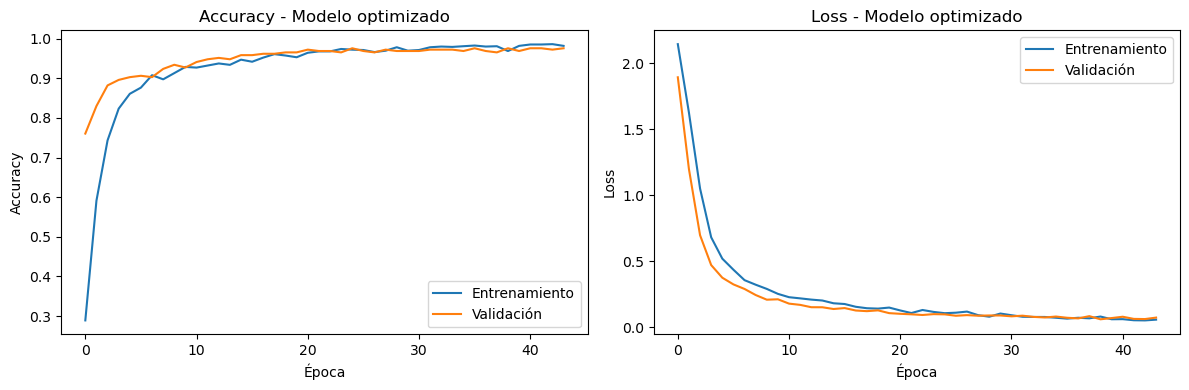

In [14]:
# gráficos del modelo optimizado
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(historial_opt.history['accuracy'], label='Entrenamiento')
axes[0].plot(historial_opt.history['val_accuracy'], label='Validación')
axes[0].set_title('Accuracy - Modelo optimizado')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(historial_opt.history['loss'], label='Entrenamiento')
axes[1].plot(historial_opt.history['val_loss'], label='Validación')
axes[1].set_title('Loss - Modelo optimizado')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()


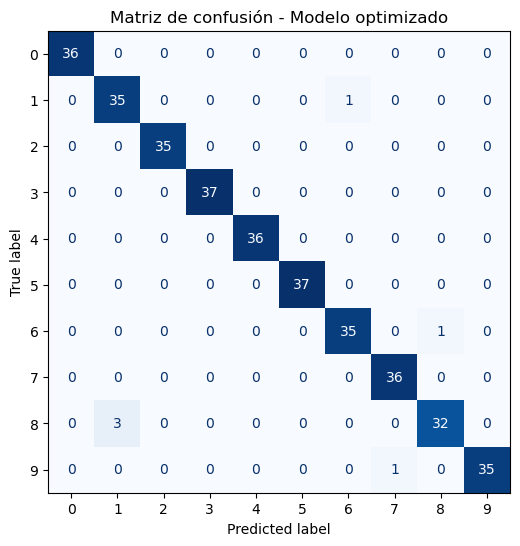

In [15]:
# matriz de confusión del modelo optimizado
y_pred_opt = np.argmax(modelo_opt.predict(X_test, verbose=0), axis=1)
cm_opt = confusion_matrix(y_test, y_pred_opt)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_opt, display_labels=range(10))
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Matriz de confusión - Modelo optimizado')
plt.show()


## 5. Comparación de resultados y reflexión

| Modelo | Accuracy en test | Loss en test |
|---|---|---|
| Base | 95.8% | 	0.1296 |
| Optimizado | 98.3% | 	0.0646 |


In [19]:
print("Comparación final")
print(f"Modelo base       -> accuracy: {acc_base:.4f} | loss: {loss_base:.4f}")
print(f"Modelo optimizado -> accuracy: {acc_opt:.4f}  | loss: {loss_opt:.4f}")


Comparación final
Modelo base       -> accuracy: 0.9583 | loss: 0.1296
Modelo optimizado -> accuracy: 0.9833  | loss: 0.0646


**Reflexión:**

Los 2 modelos sacaron buen desempeño (esperable porque el dataset es simple), pero si se ve una diferencia:

- El modelo base llega a un accuracy de 95.83% con un loss de 0.1296. Bueno,
  pero el loss más alto muestra que kaunque acierta casi siempre, esta menos seguro
  de las predicciones y es más propenso a memorizar datos si se
  sigue entrenando por muchas epocas (overfitting).
- El modelo optimizado,sube a 98.33% de accuracy y baja el
  loss a 0.0646, menos de la mitad que el modelo base. Eso gracias a que el Dropout apaga neuronas al azar en
  cada paso para que la red no dependa demasiado de unas pocas, y el EarlyStopping detiene el
  entrenamiento automáticamente en el punto justo donde el modelo deja de mejorar.
- En la matriz de confusión del modelo optimizado, los pocos errores que quedan estan
  en el 8 confundido con el 1, y el 9 confundido con el 7.

Según eso, el ajustar hiperparámetros y aplicar regularización (Dropout,
EarlyStopping) mejora el accuracy y reduce el
loss a menos de la mitad, dando un modelo más estable y menos propenso a sobreajustarse a
los datos de entrenamiento.
